In [1]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import os
from tqdm import tqdm
import glob

### This is the note on how to load simulated Hinode data from the SPIn4D Data Release 2

#### First, get the path directory, for both simulation and stokes, and the index number

In [2]:
path_stokes='/home/yangkai/koa_scratch/ToAndrew'
path_sim='/home/yangkai/koa_scratch/spin4d_bak/'
index='096480'
caseid='ssd100'
subdir='SPIN4D_SSD_100G'


In [3]:
simulation_file=f'{path_sim}/{subdir}/spin4d-{caseid}-{index}-Hinode.h5'
stokes_file=f'{path_stokes}/{subdir}/spin4d-{caseid}-{index}-6302-stokes-Hinode.h5'

#### Magnetic field unit is 3.5449077018110318 that is $\sqrt{4\pi}$
#### Temperature unit is K.
#### The variable "tau" is acctually the geometric height in the unit of km.
#### Velocity unit is cm/s

In [4]:
labels=['Bx', 'By', 'Bz', 'T', 'logP', 'tau', 'vz']
units=[np.sqrt(4*np.pi),np.sqrt(4*np.pi),np.sqrt(4*np.pi),1,1,1,1]
data={}
with h5py.File(simulation_file,'r') as f:
    for l in tqdm(labels):
        data[l]=np.array(f[l])
    print(f.keys())

100%|██████████| 7/7 [00:00<00:00, 147.17it/s]

<KeysViewHDF5 ['Bx', 'By', 'Bz', 'T', 'logP', 'tau', 'vz']>


## <span style="color:red">Attention: the Stokes axis order is incorrect.</span>
## <span style="color:red">The 1st axis is Y and the 2nd axis is X.</span>
## <span style="color:red">Swap the first two axes with <code>.transpose(1, 0, 2, 3)</code>.</span>


In [5]:
with h5py.File(stokes_file,'r') as f:
    stokes=np.array(f['stokes']).transpose(1, 0, 2, 3)
    base_wl = f.attrs['lambda_zeropoint']
    wavelength=np.array(f['lambda'])+base_wl
    print(f.keys())

<KeysViewHDF5 ['lambda', 'stokes']>


## Now the 1st is X, 2nd is Y.
## 3rd in simulation is Z.
## 3rd in Stokes is polarization state.
## 4th in Stokes is wavelength

In [6]:
ltau_final = np.linspace(1.0, -4, 11)

#### base_wl is the base value of the wavelength, thus the absolute wavelength should be f['lambda']+base_wl
#### The atmospheric parameters are sampled at multiple optical depth, from 1 to -4 with 11 sample points.

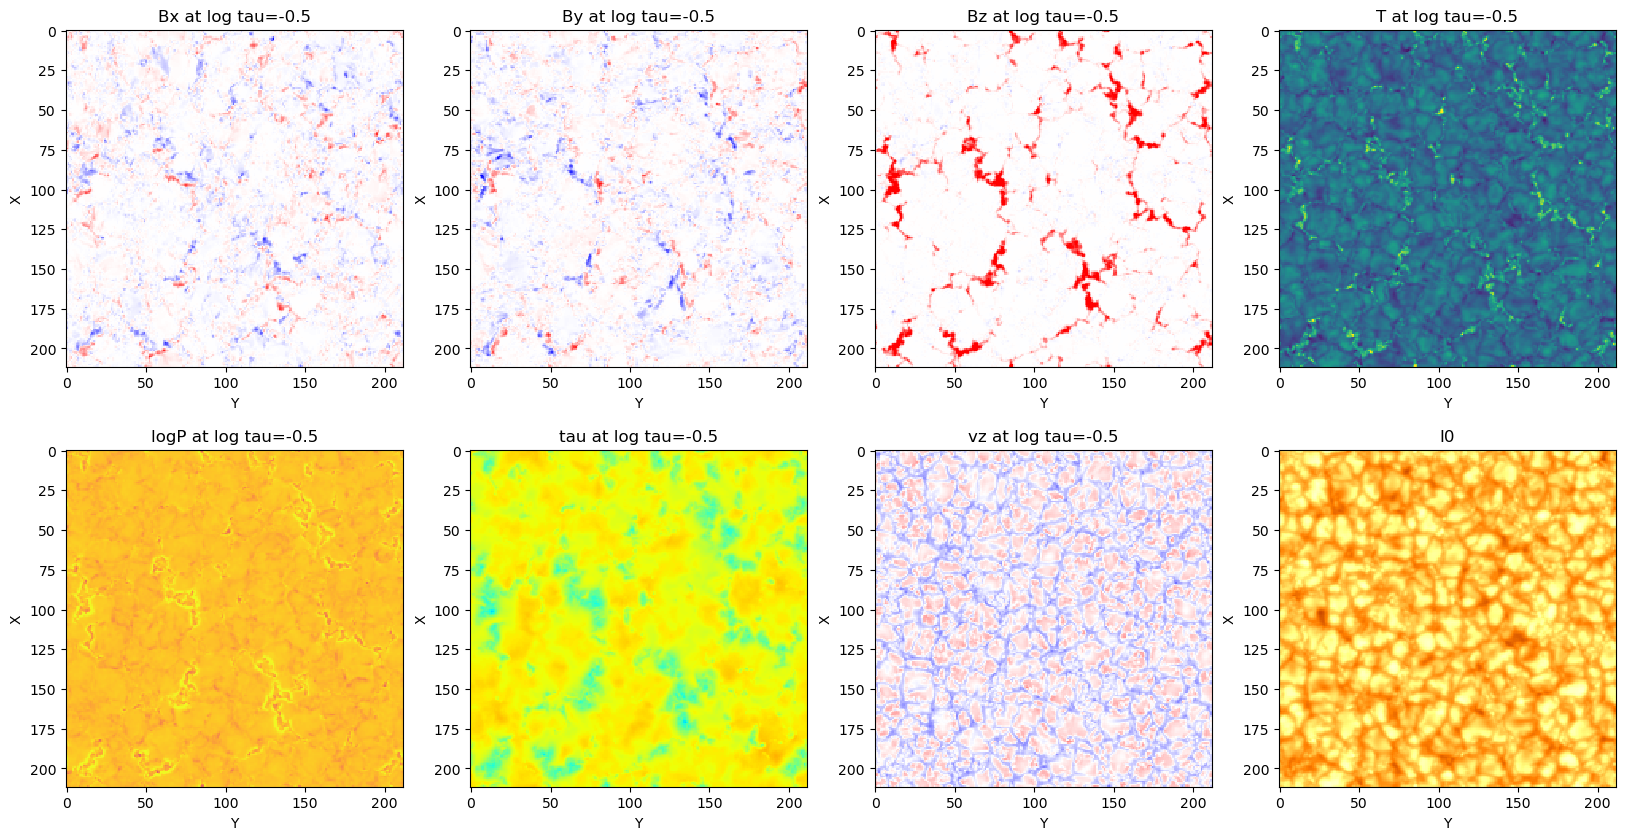

In [7]:
fig,axes=plt.subplots(2,4,figsize=(20,10))
axes=axes.flatten()
ih=3
cmaps=['bwr','bwr','bwr','viridis','plasma','jet','bwr','afmhot']
vmaxs=[2e2,2e2,5e2,6500,5,1600,1e6,1.2]
vmins=[-2e2,-2e2,-5e2,5000,4,300,-1e6,0.5]

for idx in range(8):
    axes[idx].set_xlabel('Y')
    axes[idx].set_ylabel('X')
    if idx <7:
        axes[idx].imshow(data[labels[idx]][...,ih],cmap=cmaps[idx],vmax=vmaxs[idx],vmin=vmins[idx],interpolation='none')
        axes[idx].set_title(f'{labels[idx]} at log tau={ltau_final[ih]}')
    else:
        axes[idx].imshow(stokes[...,0,0],cmap=cmaps[idx],vmax=vmaxs[idx],vmin=vmins[idx],interpolation='none')
        axes[idx].set_title('I0')     



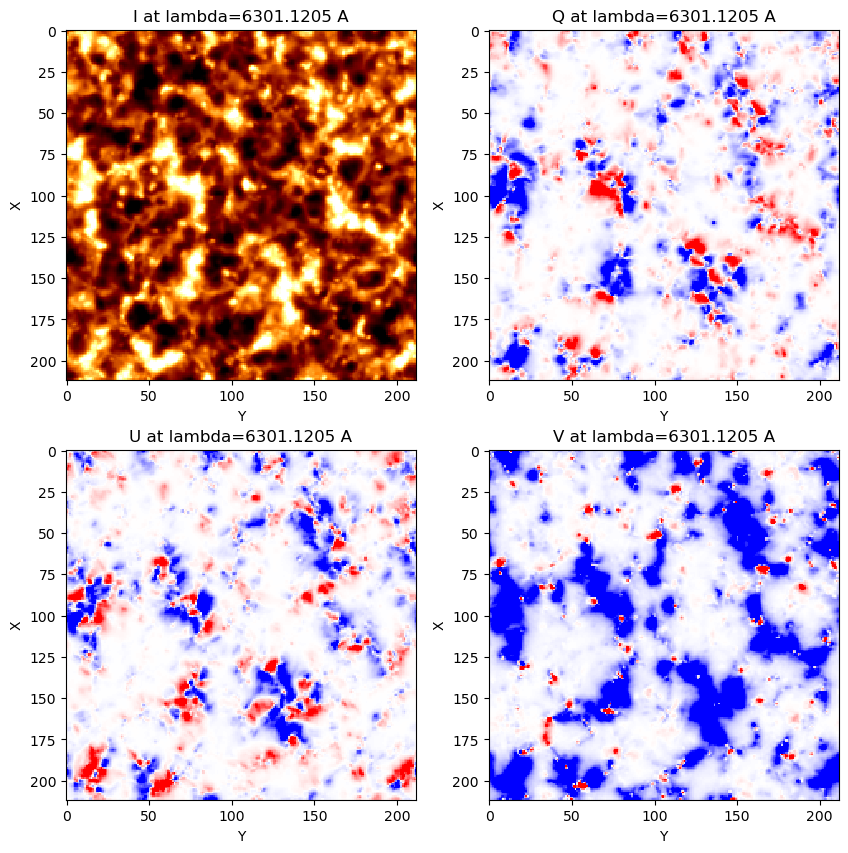

In [8]:
fig,axes=plt.subplots(2,2,figsize=(10,10))
axes=axes.flatten()
iw=30
cmaps=['afmhot','bwr','bwr','bwr']
vmaxs=[0.5,1e-3,1e-3,1e-2]
vmins=[0.2,-1e-3,-1e-3,-1e-2]
stokesid=['I','Q','U','V']

for idx in range(4):
    axes[idx].set_xlabel('Y')
    axes[idx].set_ylabel('X')

    axes[idx].imshow(stokes[...,idx,iw],cmap=cmaps[idx],vmax=vmaxs[idx],vmin=vmins[idx],interpolation='none')
    axes[idx].set_title(f'{stokesid[idx]} at lambda={wavelength[iw]*1e-3:.4f} A')
